In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, pearsonr, pointbiserialr
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import r2_score, classification_report, mean_squared_error, mean_absolute_error, confusion_matrix

In [ ]:
df = pd.read_csv('car_prices.csv')

In [ ]:
print(f"Jumlah data asli: {len(df)}\n")
print("\nJumlah baris duplikat:", df.duplicated().sum())
pd.DataFrame({
    'missing_value' : df.isnull().sum(),
    'missing_value_percentage' : df.isnull().sum() / len(df) * 100
})

Jumlah data asli: 558837


Jumlah baris duplikat: 0


,missing_value,missing_value_percentage
year,0,0.000000
make,10301,1.843292
model,10399,1.860829
trim,10651,1.905922
body,13195,2.361154
transmission,65352,11.694287
vin,4,0.000716
state,0,0.000000
condition,11820,2.115107
odometer,94,0.016821


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

with open('unique_values.txt', 'w') as f:
    for col in df.columns:
        f.write(col + '\n')
        f.write(str(list(df[col].unique())) + '\n\n')

year
[2015 2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002
 2001 2000 1999 1998 1995 1996 1997 1987 1994 1993 1992 1989 1991 1990
 1986 1985 1988 1984 1982 1983]

make
['Kia' 'BMW' 'Volvo' 'Nissan' 'Chevrolet' 'Audi' 'Ford' 'Hyundai' 'Buick'
 'Cadillac' 'Acura' 'Lexus' 'Infiniti' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Mazda' 'MINI' 'Land Rover' 'Lincoln' 'lincoln' 'Jaguar' 'Volkswagen'
 'Toyota' 'Subaru' 'Scion' 'Porsche' nan 'bmw' 'Dodge' 'FIAT' 'Chrysler'
 'ford' 'Ferrari' 'Honda' 'GMC' 'mitsubishi' 'Ram' 'smart' 'chevrolet'
 'Bentley' 'chrysler' 'pontiac' 'Pontiac' 'Saturn' 'Maserati' 'Mercury'
 'HUMMER' 'landrover' 'cadillac' 'land rover' 'mercedes' 'mazda' 'toyota'
 'lexus' 'gmc truck' 'honda' 'nissan' 'porsche' 'Saab' 'Suzuki' 'dodge'
 'subaru' 'Oldsmobile' 'oldsmobile' 'hyundai' 'jeep' 'Isuzu' 'dodge tk'
 'Geo' 'acura' 'volkswagen' 'suzuki' 'kia' 'audi' 'Rolls-Royce' 'gmc'
 'maserati' 'mazda tk' 'mercury' 'buick' 'hyundai tk' 'mercedes-b' 'vw'
 'Daewoo' 'chev tru

In [ ]:
cols = ['make', 'transmission', 'body', 'model']
for col in cols:
    df[col] = df[col].str.lower().str.strip()

koreksi = {
    'mercedes': 'mercedes-benz',
    'mercedes-b': 'mercedes-benz',
    'vw': 'volkswagen',
    'land rover': 'landrover',
    'gmc truck': 'gmc',
    'dodge tk': 'dodge',
    'mazda tk': 'mazda',
    'hyundai tk': 'hyundai',
    'ford tk': 'ford',
    'ford truck': 'ford',
    'chevrolet tk': 'chevrolet',
    'chev truck': 'chevrolet',
}
df['make'] = df['make'].replace(koreksi)

koreksi1 = {
    'f-150': 'f150'
}
df['model'] = df['model'].replace(koreksi1)


koreksi2 = {
    'regular-cab': 'regularcab',
    'land rover': 'landrover',
    'access cab': 'accesscab',
}
df['body'] = df['body'].replace(koreksi2)

koreksi3 = {
    'g coupe': 'coupe', 'elantra coupe': 'coupe', 'genesis coupe': 'coupe',
    'cts coupe': 'coupe', 'cts-v coupe': 'coupe', 'koup': 'coupe',
    'g37 coupe': 'coupe', 'q60 coupe': 'coupe',

    'g sedan': 'sedan',

    'g convertible': 'convertible', 'g37 convertible': 'convertible',
    'q60 convertible': 'convertible', 'beetle convertible': 'convertible',
    'granturismo convertible': 'convertible',

    'cts wagon': 'wagon', 'tsx sport wagon': 'wagon', 'cts-v wagon': 'wagon',

    'minivan': 'van', 'e-series van': 'van', 'promaster cargo van': 'van',
    'transit van': 'van', 'ram van': 'van',

    'crew cab': 'pickup', 'double cab': 'pickup', 'crewmax cab': 'pickup',
    'supercrew': 'pickup', 'quad cab': 'pickup', 'mega cab': 'pickup',
    'extended cab': 'pickup', 'access cab': 'pickup', 'king cab': 'pickup',
    'supercab': 'pickup', 'club cab': 'pickup', 'xtracab': 'pickup',
    'cab plus': 'pickup', 'cab plus 4': 'pickup',
    'regular cab': 'pickup', 'regular-cab': 'pickup', 'regularcab' : 'pickup',

    'navitgation': np.nan
}
df['body'] = df['body'].replace(koreksi3)

df['transmission'] = df['transmission'].replace('sedan', np.nan)

df['color'] = df['color'].replace('—', np.nan)
df['interior'] = df['interior'].replace('—', np.nan)

df['color'] = df['color'].apply(lambda x: np.nan if str(x).isnumeric() else x)

df = df[df['state'].astype(str).str.len() == 2]

df['condition'] = df['condition'].apply(lambda x: x/10 if x > 5 else x)

In [ ]:
#cari inconsistencies
for col in df.columns:
    print(col)
    print(df[col].unique())
    print()

with open('unique_values_new.txt', 'w') as f:
    for col in df.columns:
        f.write(col + '\n')
        f.write(str(list(df[col].unique())) + '\n\n')



year
[2015 2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 2004 2003 2002
 2001 2000 1999 1998 1995 1996 1997 1987 1994 1993 1992 1989 1991 1990
 1986 1985 1988 1984 1982 1983]

make
['kia' 'bmw' 'volvo' 'nissan' 'chevrolet' 'audi' 'ford' 'hyundai' 'buick'
 'cadillac' 'acura' 'lexus' 'infiniti' 'jeep' 'mercedes-benz' 'mitsubishi'
 'mazda' 'mini' 'landrover' 'lincoln' 'jaguar' 'volkswagen' 'toyota'
 'subaru' 'scion' 'porsche' nan 'dodge' 'fiat' 'chrysler' 'ferrari'
 'honda' 'gmc' 'ram' 'smart' 'bentley' 'pontiac' 'saturn' 'maserati'
 'mercury' 'hummer' 'saab' 'suzuki' 'oldsmobile' 'isuzu' 'geo'
 'rolls-royce' 'daewoo' 'plymouth' 'tesla' 'airstream' 'dot'
 'aston martin' 'fisker' 'lamborghini' 'lotus']

model
['sorento' '3 series' 's60' '6 series gran coupe' 'altima' 'm5' 'cruze'
 'a4' 'camaro' 'a6' 'optima' 'fusion' 'sonata' 'q5' '6 series' 'impala'
 '5 series' 'a3' 'xc70' 'x5' 'sq5' 's5' 'verano' 'suburban' 'elr' 'v60'
 'x6' 'ilx' 'k900' 'malibu' 'rx 350' 'versa' 'elantra' 'versa not

In [ ]:
df_clean = df.copy()
#hapus baris dengan kolom kosong
cols1 = ['make', 'model', 'trim', 'body', 'transmission', 'vin', 'condition', 'sellingprice', 'saledate']
df_clean = df_clean.dropna(subset=cols1)

print(f"Jumlah data bersih: {len(df_clean)}")

#ganti data dengan median
df_clean['odometer'] = df_clean['odometer'].fillna(df_clean['odometer'].median())
df_clean['mmr'] = df_clean['mmr'].fillna(df_clean['mmr'].median())
#ganti kolom kosong dengan N/A
df_clean['color'] = df_clean['color'].fillna('N/A')
df_clean['interior'] = df_clean['interior'].fillna('N/A')

Jumlah data bersih: 472891


In [ ]:
print(f"Jumlah data setelah handling missing value: {len(df)}\n")
print("\nJumlah baris duplikat:", df_clean.duplicated().sum())
pd.DataFrame({
    'missing_value' : df_clean.isnull().sum(),
    'missing_value_percentage' : df_clean.isnull().sum() / len(df_clean) * 100
})

Jumlah data setelah handling missing value: 558811


Jumlah baris duplikat: 0


,missing_value,missing_value_percentage
year,0,0.0
make,0,0.0
model,0,0.0
trim,0,0.0
body,0,0.0
transmission,0,0.0
vin,0,0.0
state,0,0.0
condition,0,0.0
odometer,0,0.0


Jumlah data asli: 472891


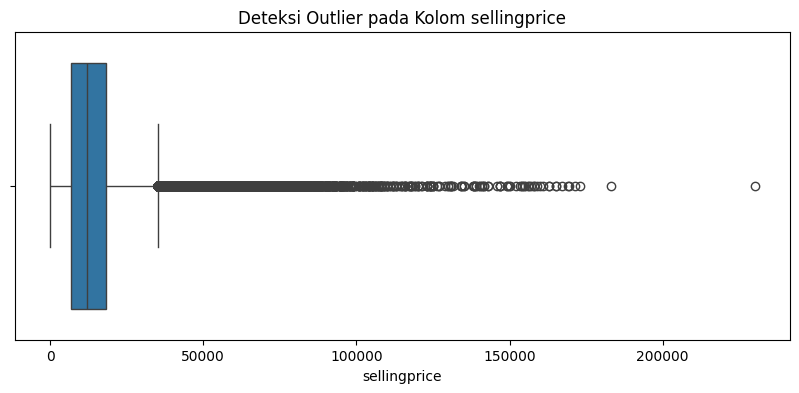

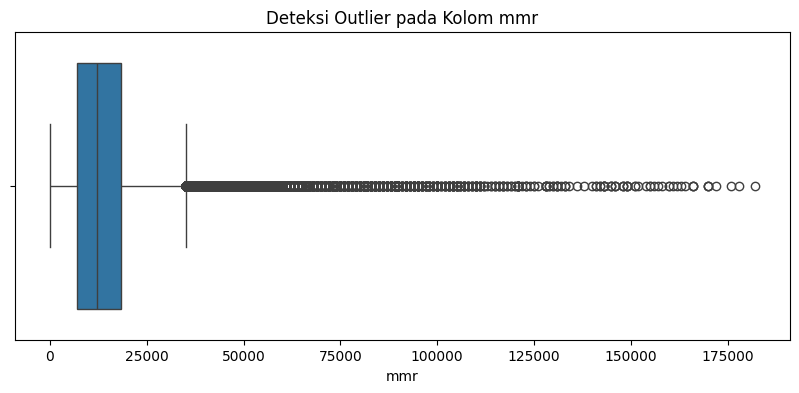

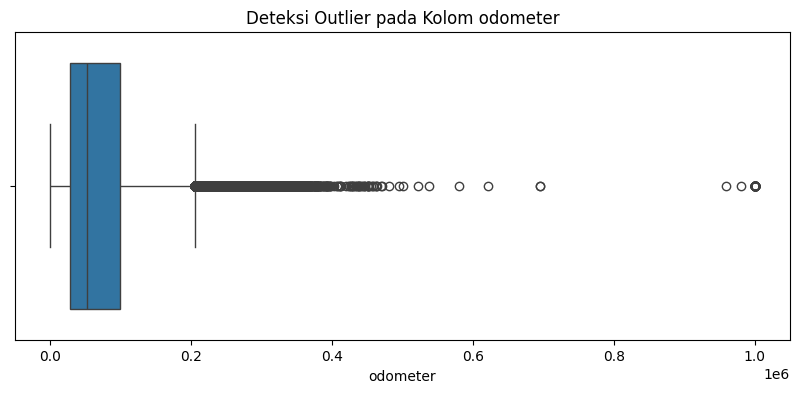

Jumlah outliers sellingprice: 14243
Jumlah outliers mmr: 3469
Jumlah outliers odometer: 8266
Jumlah data bersih: 446913


In [ ]:
#outliers
cols = ['sellingprice', 'mmr', 'odometer']
print(f"Jumlah data asli: {len(df_clean)}")

for col in cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col].dropna())
    plt.title(f'Deteksi Outlier pada Kolom {col}')
    plt.show()

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    #cari outliers
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"Jumlah outliers {col}: {len(outliers)}")
    #buang sisa
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f"Jumlah data bersih: {len(df_clean)}")

In [ ]:
df_clean['price_diff'] = df_clean['sellingprice'] - df_clean['mmr']
df_clean['saledate'] = pd.to_datetime(df_clean['saledate'], utc=True, errors='coerce')
df_clean['car_age'] = df_clean['saledate'].dt.year - df_clean['year']
df_clean = df_clean[df_clean['car_age'] >= 0]

/tmp/ipykernel_5594/2231886667.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['saledate'] = pd.to_datetime(df_clean['saledate'], utc=True, errors='coerce')


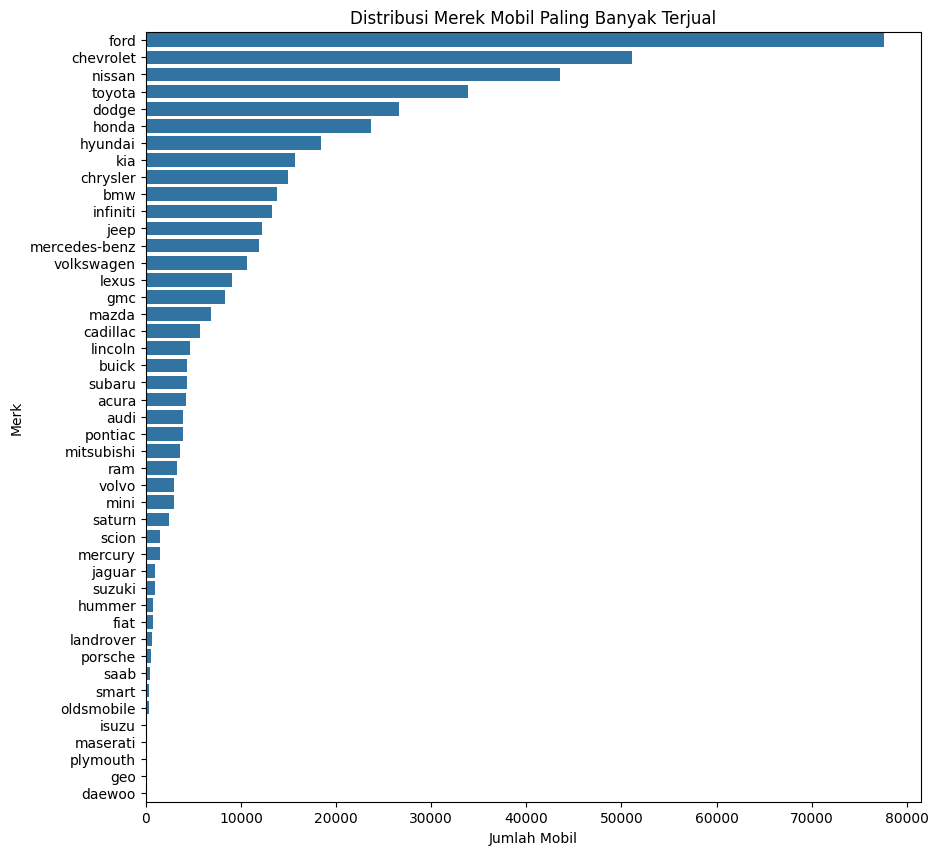

In [ ]:
plt.figure(figsize=(10, 10))

merek_berurutan = df_clean['make'].value_counts().index
sns.countplot(data=df_clean, y='make', order=merek_berurutan)

plt.title('Distribusi Merek Mobil Paling Banyak Terjual')
plt.xlabel('Jumlah Mobil')
plt.ylabel('Merk')

plt.show()

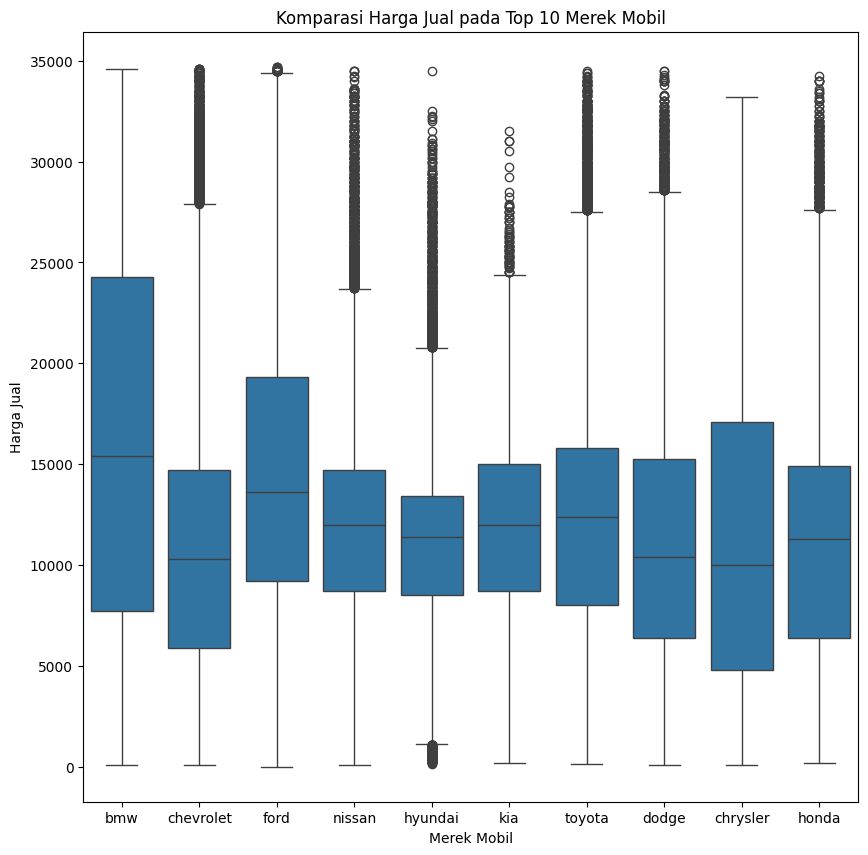

In [ ]:
plt.figure(figsize=(10, 10))
top_10_makes = df_clean['make'].value_counts().nlargest(10).index
df_top10 = df_clean[df_clean['make'].isin(top_10_makes)]

sns.boxplot(data=df_top10, x='make', y='sellingprice')

plt.title('Komparasi Harga Jual pada Top 10 Merek Mobil')
plt.xlabel('Merek Mobil')
plt.ylabel('Harga Jual')

plt.show()

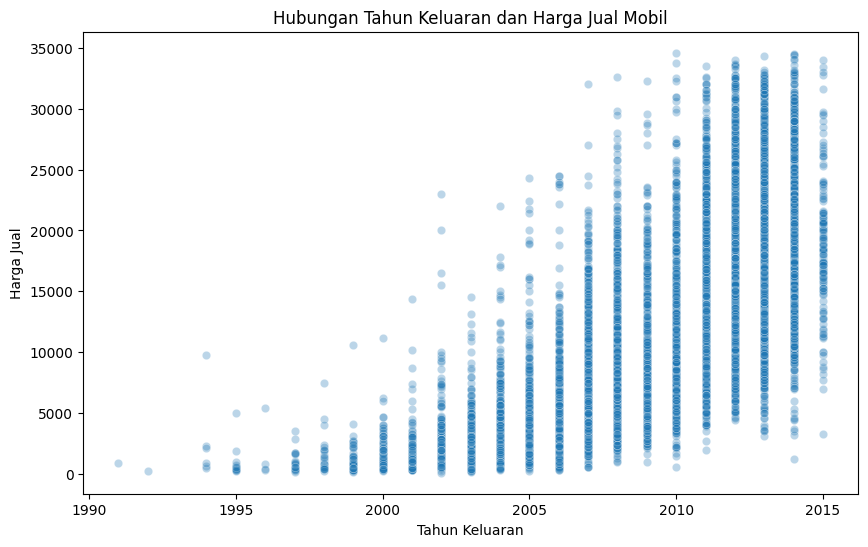

In [ ]:
plt.figure(figsize=(10, 6))

# data terlalu banyak ambil sample aja sama pake random_state biar sample yang diambil sama terus
df_sample = df_clean.sample(10000, random_state=1)

sns.scatterplot(data=df_sample, x='year', y='sellingprice', alpha=0.3)

plt.title('Hubungan Tahun Keluaran dan Harga Jual Mobil')
plt.xlabel('Tahun Keluaran')
plt.ylabel('Harga Jual')

plt.show()

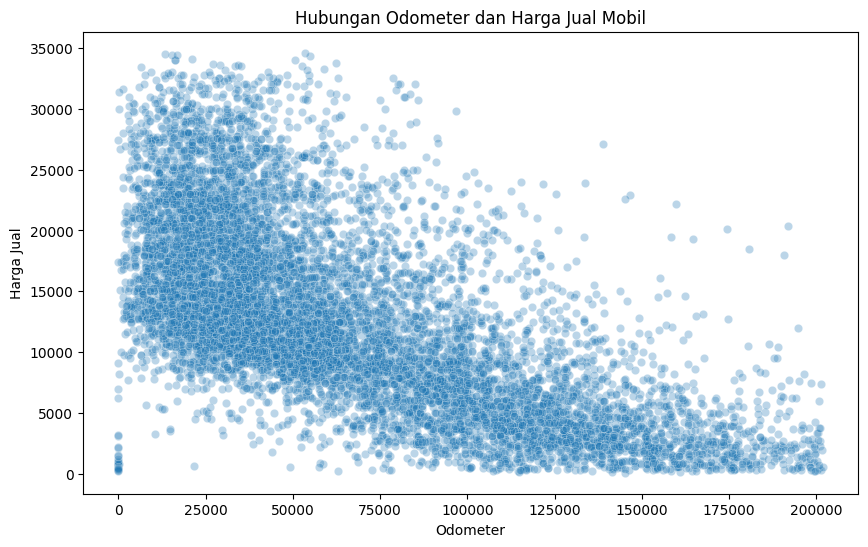

In [ ]:
plt.figure(figsize=(10, 6))

# data terlalu banyak ambil sample aja sama pake random_state biar sample yang diambil sama terus
df_sample = df_clean.sample(10000, random_state=1)

sns.scatterplot(data=df_sample, x='odometer', y='sellingprice', alpha=0.3)

plt.title('Hubungan Odometer dan Harga Jual Mobil')
plt.xlabel('Odometer')
plt.ylabel('Harga Jual')

plt.show()

In [ ]:
numerical_cols =  df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

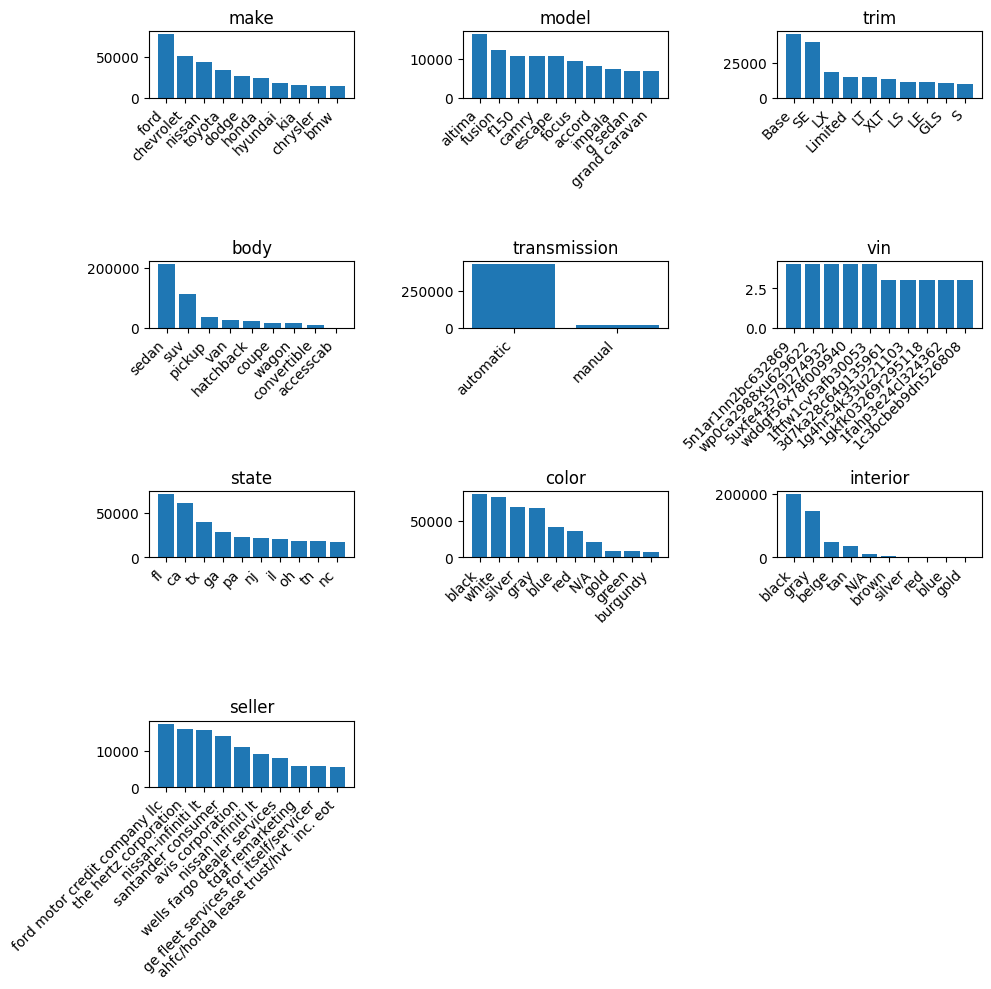

In [ ]:
def check_univariate_categorical(df_clean, catCols, top_n=10):
    n = len(catCols)
    rows = -(-n//3)
    plt.figure(figsize=(10,10))
    for i, col in enumerate(catCols, 1):
        plt.subplot(rows, 3, i)
        count = df_clean[col].value_counts()
        if len(count) > top_n:
            count = count.head(top_n)
        plt.bar(count.index, count.values)
        plt.title(col)
        plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

check_univariate_categorical(df_clean, categorical_cols, top_n=10)

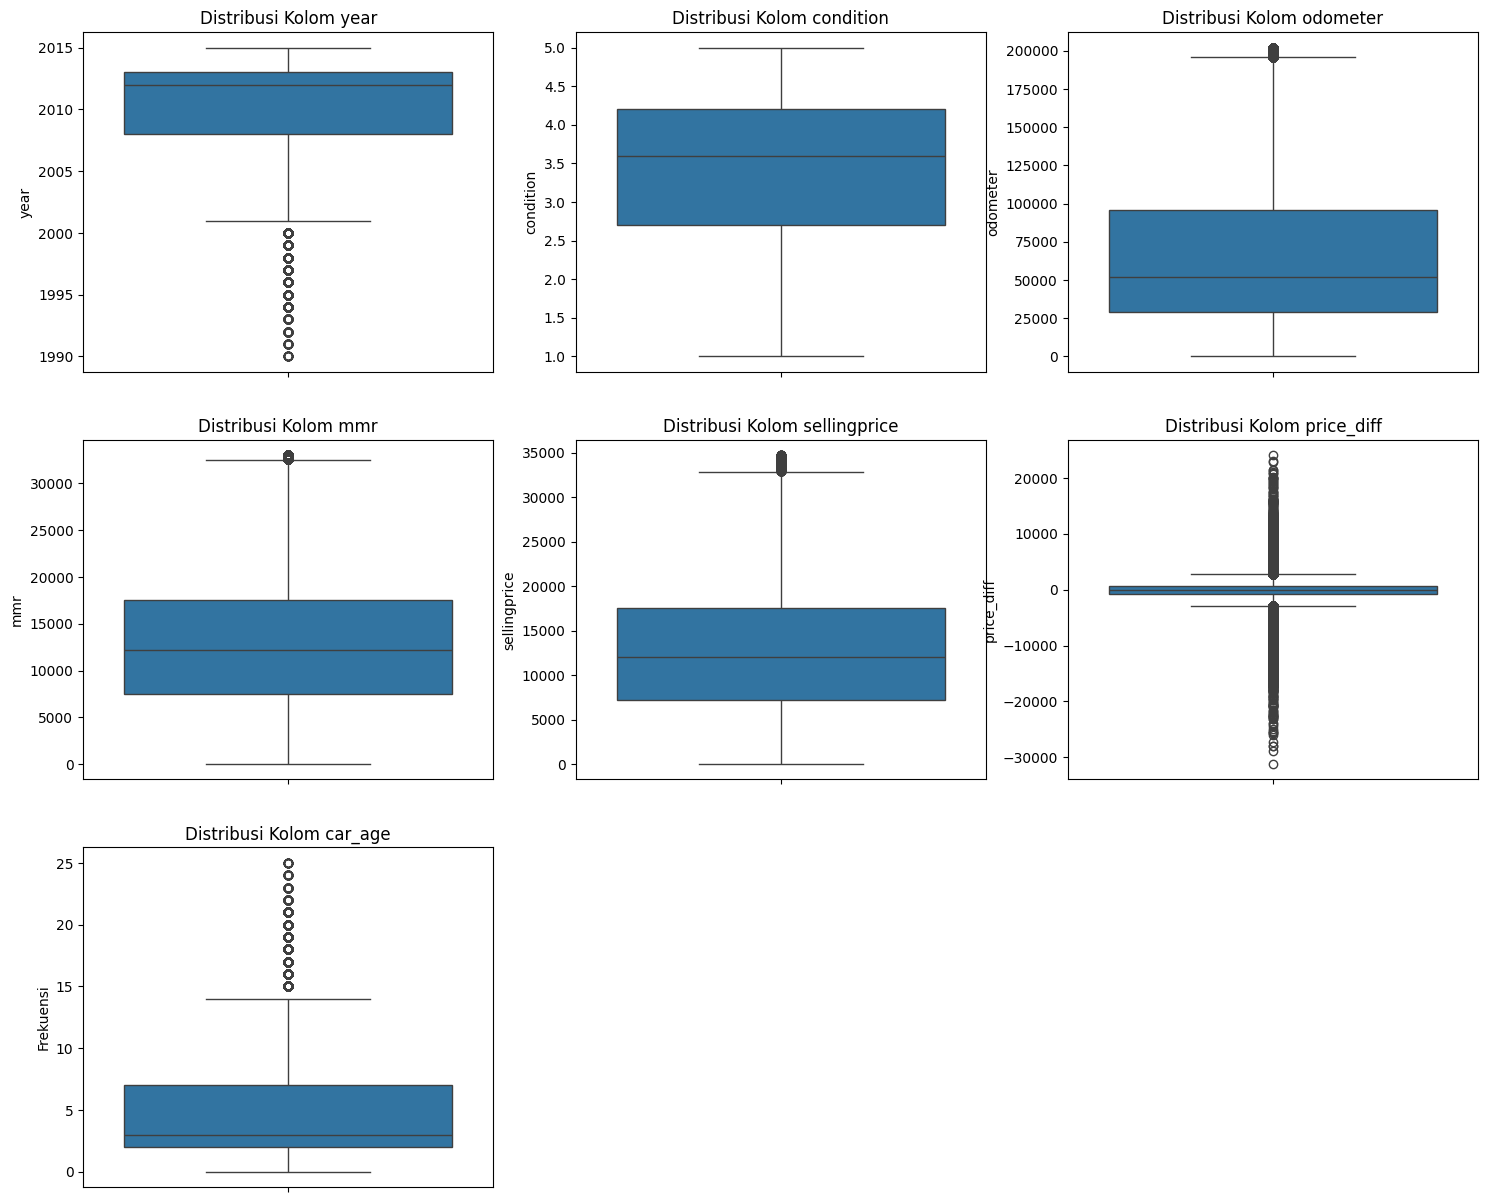

In [ ]:
def check_univariate_numerical(df, numerical_cols):
    n = len(numerical_cols)
    rows = -(-n // 3)
    plt.figure(figsize=(18, rows * 5))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(rows, 3, i)
        sns.boxplot(df[col])
        plt.title(f'Distribusi Kolom {col}')
    plt.ylabel('Frekuensi')
    plt.show()

check_univariate_numerical(df_clean, numerical_cols)

In [ ]:
df_clean = df_clean.drop(columns=['vin', 'year', 'saledate', 'seller','price_diff'])
TARGETREG = 'sellingprice'
x = df_clean.drop(columns=[TARGETREG])
y = df_clean[TARGETREG]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2
)

In [ ]:
numerical_cols = x_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = x_train.select_dtypes(include=['object']).columns.tolist()

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train[categorical_cols] = oe.fit_transform(x_train[categorical_cols])
x_test[categorical_cols] = oe.transform(x_test[categorical_cols])

In [ ]:
mi_score = mutual_info_regression(x_train, y_train)
mi_df = pd.DataFrame({
    'features' : x_train.columns,
    'mi_score' : mi_score
})
print(mi_df)

        features  mi_score
0           make  0.171087
1          model  0.515187
2           trim  0.402646
3           body  0.077163
4   transmission  0.002108
5          state  0.094388
6      condition  0.247342
7       odometer  0.386676
8          color  0.029011
9       interior  0.038538
10           mmr  1.660231
11       car_age  0.410801


In [ ]:
select_feature = mi_df[mi_df['mi_score'] > 0]['features'].tolist()
print(select_feature)

x_train_selected = x_train[select_feature]
x_test_selected = x_test[select_feature]

['make', 'model', 'trim', 'body', 'transmission', 'state', 'condition', 'odometer', 'color', 'interior', 'mmr', 'car_age']


In [ ]:
rf = RandomForestRegressor()
rf.fit(x_train_selected, y_train)
y_pred = rf.predict(x_test_selected)

In [ ]:
print("hasil sebelum tuning")

print("prediksi train")
print(f"MAE  : {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R2   : {r2_score(y_train, y_pred_train):.4f}")

print("prediksi test")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2   : {r2_score(y_test, y_pred):.4f}")

hasil sebelum tuning
prediksi train
MAE  : 566.35
RMSE : 836.77
R2   : 0.9872
prediksi test
MAE  : 885.32
RMSE : 1339.62
R2   : 0.9672


In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    max_features=None,
    min_samples_split=3,
    min_samples_leaf=5
)

rf.fit(x_train_selected, y_train)

RandomForestRegressor(max_depth=10, max_features=None, min_samples_leaf=5,
                      min_samples_split=3, n_estimators=200)

In [ ]:
y_pred = rf.predict(x_test_selected)

In [ ]:
print("hasil sesudah tuning")

print("prediksi train")
print(f"MAE  : {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R2   : {r2_score(y_train, y_pred_train):.4f}")

print("prediksi test")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2 : {r2_score(y_test, y_pred):.4f}")

hasil sesudah tuning
prediksi train
MAE  : 566.35
RMSE : 836.77
R2   : 0.9872
prediksi test
MAE: 894.92
RMSE: 1347.61
R2 : 0.9668


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200],
    'max_depth': [20, 30],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=2
)

grid_search.fit(x_train_selected, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=2,
             param_grid={'max_depth': [20, 30], 'min_samples_leaf': [1, 2],
                         'n_estimators': [200]},
             scoring='r2')

In [ ]:
best_model = grid_search.best_estimator_
y_pred_grid = best_model.predict(x_test_selected)

print("Evaluation of the best model after GridSearchCV:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_grid):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_grid)):.2f}")
print(f"R2 : {r2_score(y_test, y_pred_grid):.4f}")

Evaluation of the best model after GridSearchCV:
MAE: 875.99
RMSE: 1327.35
R2 : 0.9678


In [ ]:
best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(x_train_selected)

print("Hasil Tuning dengan GridSearchCV")
print("prediksi train")
print(f"MAE : {mean_absolute_error(y_train, y_pred_train):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}")
print(f"R2  : {r2_score(y_train, y_pred_train):.4f}")

y_pred_test = best_model.predict(x_test_selected)
print("prediksi test")
print(f"MAE : {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.2f}")
print(f"R2  : {r2_score(y_test, y_pred_test):.4f}")

Hasil Tuning dengan GridSearchCV
prediksi train
MAE : 566.35
RMSE: 836.77
R2  : 0.9872
prediksi test
MAE : 875.99
RMSE: 1327.35
R2  : 0.9678
